# Programming basics

In [1]:
# Imports

library(dslabs)
library(dplyr)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




This chapter handles basic flow control and functions in R and should (mostly) be pretty straightforward. However, before going into the main subject matter, the text briefly mentions but does not explain several functions that might be used in more advanced R programming. These are: `split()`, `cut()`, `do.call()` and `Reduce()`.

## Conditional expressions

Anyway, here's a basic `if` expression in R (and notice that it has a return value):

In [2]:
a <- 0

if (a != 0) {
    1 / a
} else {
    'No reciprocal for 0.'
}

[1] "No reciprocal for 0."

The book further advises us of an example of an `if` expression that's used to detect a very low homicide rate:

In [3]:
murder_rate <- with(murders, total / population * 10^5)
ind <- which.min(murder_rate)

if (murder_rate[ind] < 0.5) {
    murders$state[ind]
} else {
    'No state has a homicide rate that low.'
}

[1] "Vermont"

The `else` branch gets evaluated if we try again with a homicide rate less than 0.25:

In [4]:
if (murder_rate[ind] < 0.25) {
    murders$state[ind]
} else {
    'No state has a homicide rate that low.'
}

[1] "No state has a homicide rate that low."

While `if` expressions obviously exist in R, vectorized operations are more common. `ifelse()` does a vectorized sort of `if`/`else` where a predicate is evaluated and each element of the returned vector depends on whether the corresponding entry in the predicate was true, in which case the matching element from the second argument is taken, and from the third argument otherwise. Best to give an example and note that it uses recycling with `NA`:

In [5]:
a <- c(0, 1, 2, -4, 5)
ifelse(a > 0, 1 / a, NA)

[1]  NA 1.0 0.5  NA 0.2

A less artificial example can be seen with `na_example` from dslabs:

In [6]:
na_example

[1]  2  1  3  2  1  3  1  4  3  2  2 NA  2  2  1  4 NA  1  1  2  1  2  2  1
  [25]  2  5 NA  2  2  3  1  2  4  1  1  1  4  5  2  3  4  1  2  4  1  1  2  1
  [49]  5 NA NA NA  1  1  5  1  3  1 NA  4  4  7  3  2 NA NA  1 NA  4  1  2  2
  [73]  3  2  1  2  2  4  3  4  2  3  1  3  2  1  1  1  3  1 NA  3  1  2  2  1
  [97]  2  2  1  1  4  1  1  2  3  3  2  2  3  3  3  4  1  1  1  2 NA  4  3  4
 [121]  3  1  2  1 NA NA NA NA  1  5  1  2  1  3  5  3  2  2 NA NA NA NA  3  5
 [145]  3  1  1  4  2  4  3  3 NA  2  3  2  6 NA  1  1  2  2  1  3  1  1  5 NA
 [169] NA  2  4 NA  2  5  1  4  3  3 NA  4  3  1  4  1  1  3  1  1 NA NA  3  5
 [193]  2  2  2  3  1  2  2  3  2  1 NA  2 NA  1 NA NA  2  1  1 NA  3 NA  1  2
 [217]  2  1  3  2  2  1  1  2  3  1  1  1  4  3  4  2  2  1  4  1 NA  5  1  4
 [241] NA  3 NA NA  1  1  5  2  3  3  2  4 NA  3  2  5 NA  2  3  4  6  2  2  2
 [265] NA  2 NA  2 NA  3  3  2  2  4  3  1  4  2 NA  2  4 NA  6  2  3  1 NA  2
 [289]  2 NA  1  1  3  2  3  3  1 NA  1  4  2  1  1  3  2  1  2  3  1 NA  2  3
 [313]  3  2  1  2  3  5  5  1  2  3  3  1 NA NA  1  2  4 NA  2  1  1  1  3  2
 [337]  1  1  3  4 NA  1  2  1  1  3  3 NA  1  1  3  5  3  2  3  4  1  4  3  1
 [361] NA  2  1  2  2  1  2  2  6  1  2  4  5 NA  3  4  2  1  1  4  2  1  1  1
 [385]  1  2  1  4  4  1  3 NA  3  3 NA  2 NA  1  2  1  1  4  2  1  4  4 NA  1
 [409]  2 NA  3  2  2  2  1  4  3  6  1  2  3  1  3  2  2  2  1  1  3  2  1  1
 [433]  1  3  2  2 NA  4  4  4  1  1 NA  4  3 NA  1  3  1  3  2  4  2  2  2  3
 [457]  2  1  4  3 NA  1  4  3  1  3  2 NA  3 NA  1  3  1  4  1  1  1  2  4  3
 [481]  1  2  2  2  3  2  3  1  1 NA  3  2  1  1  2 NA  2  2  2  3  3  1  1  2
 [505] NA  1  2  1  1  3  3  1  3  1  1  1  1  1  2  5  1  1  2  2  1  1 NA  1
 [529]  4  1  2  4  1  3  2 NA  1  1 NA  2  1  1  4  2  3  3  1  5  3  1  1  2
 [553] NA  1  1  3  1  3  2  4 NA  2  3  2  1  2  1  1  1  2  2  3  1  5  2 NA
 [577]  2 NA  3  2  2  2  1  5  3  2  3  1 NA  3  1  2  2  2  1  2  2  4 NA  6
 [601]  1  2 NA  1  1  2  2  3 NA  3  2  3  3  4  2 NA  2 NA  4 NA  1  1  2  2
 [625]  3  1  1  1  3 NA  2  5 NA  7  1 NA  4  3  3  1 NA  1  1  1  1  3  2  4
 [649]  2  2  3 NA NA  1  4  3  2  2  2  3  2  4  2  2  4 NA NA NA  6  3  3  1
 [673]  4  4  2  1 NA  1  6 NA  3  3  2  1  1  6 NA  1  5  1 NA  2  6  2 NA  4
 [697]  1  3  1  2 NA  1  1  3  1  2  4  2  1  3  2  4  3  2  2  1  1  5  6  4
 [721]  2  2  2  2  4 NA  1  2  2  2  2  4  5 NA NA NA  4  3  3  3  2  4  2  4
 [745] NA NA NA NA  2  1 NA  2  4  3  2 NA  2  3  1  3  4 NA  1  2  1  2 NA  3
 [769]  1  2  1  2  1  2  1  2  2  2  2  1  1  3  3  1  3  4  3 NA NA  4  2  3
 [793]  2  1  3  2  4  2  2  3  1  2  4  3  3  4 NA  1  4  2  1  1  1  3  1  5
 [817]  2  2  4  2 NA  1  3  1  2 NA  1  2  1  2  1 NA  1  3  2  3  2 NA  2  1
 [841]  4  2 NA NA NA  2  4  2 NA NA  3  1 NA  5  5  2  2  2 NA  2  1  3  1  3
 [865]  2  4  2  4 NA  4  1  2  3  2  3  3  2  3  2  2  2  1  3  2  4  2 NA  3
 [889]  3  2  2 NA NA  3  2  1  2  4  1  1  1  1  4  3  2 NA  3  2 NA  1 NA  3
 [913]  2  1  1  1  2 NA  2  2  3  3  2 NA NA  4  5  2  2  2  1  2  3  1  3  3
 [937]  4  3 NA  1  1  1 NA  4  3  5  1  1  2 NA  2  2  2  2  5  2  2  3  1  2
 [961]  3 NA  1  2 NA NA  2 NA  3  1  1  2  5  3  5  1  1  4 NA  2  1  3  1  1
 [985]  2  4  3  3  3 NA  1  1  2  2  1  1  2  2 NA  2

Let's replace all of the `NA`s with 0:

In [7]:
no_nas <- ifelse(is.na(na_example), 0, na_example)
no_nas

[1] 2 1 3 2 1 3 1 4 3 2 2 0 2 2 1 4 0 1 1 2 1 2 2 1 2 5 0 2 2 3 1 2 4 1 1 1 4
  [38] 5 2 3 4 1 2 4 1 1 2 1 5 0 0 0 1 1 5 1 3 1 0 4 4 7 3 2 0 0 1 0 4 1 2 2 3 2
  [75] 1 2 2 4 3 4 2 3 1 3 2 1 1 1 3 1 0 3 1 2 2 1 2 2 1 1 4 1 1 2 3 3 2 2 3 3 3
 [112] 4 1 1 1 2 0 4 3 4 3 1 2 1 0 0 0 0 1 5 1 2 1 3 5 3 2 2 0 0 0 0 3 5 3 1 1 4
 [149] 2 4 3 3 0 2 3 2 6 0 1 1 2 2 1 3 1 1 5 0 0 2 4 0 2 5 1 4 3 3 0 4 3 1 4 1 1
 [186] 3 1 1 0 0 3 5 2 2 2 3 1 2 2 3 2 1 0 2 0 1 0 0 2 1 1 0 3 0 1 2 2 1 3 2 2 1
 [223] 1 2 3 1 1 1 4 3 4 2 2 1 4 1 0 5 1 4 0 3 0 0 1 1 5 2 3 3 2 4 0 3 2 5 0 2 3
 [260] 4 6 2 2 2 0 2 0 2 0 3 3 2 2 4 3 1 4 2 0 2 4 0 6 2 3 1 0 2 2 0 1 1 3 2 3 3
 [297] 1 0 1 4 2 1 1 3 2 1 2 3 1 0 2 3 3 2 1 2 3 5 5 1 2 3 3 1 0 0 1 2 4 0 2 1 1
 [334] 1 3 2 1 1 3 4 0 1 2 1 1 3 3 0 1 1 3 5 3 2 3 4 1 4 3 1 0 2 1 2 2 1 2 2 6 1
 [371] 2 4 5 0 3 4 2 1 1 4 2 1 1 1 1 2 1 4 4 1 3 0 3 3 0 2 0 1 2 1 1 4 2 1 4 4 0
 [408] 1 2 0 3 2 2 2 1 4 3 6 1 2 3 1 3 2 2 2 1 1 3 2 1 1 1 3 2 2 0 4 4 4 1 1 0 4
 [445] 3 0 1 3 1 3 2 4 2 2 2 3 2 1 4 3 0 1 4 3 1 3 2 0 3 0 1 3 1 4 1 1 1 2 4 3 1
 [482] 2 2 2 3 2 3 1 1 0 3 2 1 1 2 0 2 2 2 3 3 1 1 2 0 1 2 1 1 3 3 1 3 1 1 1 1 1
 [519] 2 5 1 1 2 2 1 1 0 1 4 1 2 4 1 3 2 0 1 1 0 2 1 1 4 2 3 3 1 5 3 1 1 2 0 1 1
 [556] 3 1 3 2 4 0 2 3 2 1 2 1 1 1 2 2 3 1 5 2 0 2 0 3 2 2 2 1 5 3 2 3 1 0 3 1 2
 [593] 2 2 1 2 2 4 0 6 1 2 0 1 1 2 2 3 0 3 2 3 3 4 2 0 2 0 4 0 1 1 2 2 3 1 1 1 3
 [630] 0 2 5 0 7 1 0 4 3 3 1 0 1 1 1 1 3 2 4 2 2 3 0 0 1 4 3 2 2 2 3 2 4 2 2 4 0
 [667] 0 0 6 3 3 1 4 4 2 1 0 1 6 0 3 3 2 1 1 6 0 1 5 1 0 2 6 2 0 4 1 3 1 2 0 1 1
 [704] 3 1 2 4 2 1 3 2 4 3 2 2 1 1 5 6 4 2 2 2 2 4 0 1 2 2 2 2 4 5 0 0 0 4 3 3 3
 [741] 2 4 2 4 0 0 0 0 2 1 0 2 4 3 2 0 2 3 1 3 4 0 1 2 1 2 0 3 1 2 1 2 1 2 1 2 2
 [778] 2 2 1 1 3 3 1 3 4 3 0 0 4 2 3 2 1 3 2 4 2 2 3 1 2 4 3 3 4 0 1 4 2 1 1 1 3
 [815] 1 5 2 2 4 2 0 1 3 1 2 0 1 2 1 2 1 0 1 3 2 3 2 0 2 1 4 2 0 0 0 2 4 2 0 0 3
 [852] 1 0 5 5 2 2 2 0 2 1 3 1 3 2 4 2 4 0 4 1 2 3 2 3 3 2 3 2 2 2 1 3 2 4 2 0 3
 [889] 3 2 2 0 0 3 2 1 2 4 1 1 1 1 4 3 2 0 3 2 0 1 0 3 2 1 1 1 2 0 2 2 3 3 2 0 0
 [926] 4 5 2 2 2 1 2 3 1 3 3 4 3 0 1 1 1 0 4 3 5 1 1 2 0 2 2 2 2 5 2 2 3 1 2 3 0
 [963] 1 2 0 0 2 0 3 1 1 2 5 3 5 1 1 4 0 2 1 3 1 1 2 4 3 3 3 0 1 1 2 2 1 1 2 2 0
[1000] 2

That no `NA`s remain can be verified with total certainty by using `sum()` on the value of `is.na()`:

In [8]:
sum(is.na(no_nas))

[1] 0

The predicates `any()` and `all()` work more or less the same as in Python:

In [9]:
z <- c(TRUE, TRUE, FALSE)
any(z)

[1] TRUE

In [10]:
all(z)

[1] FALSE

Now for a few exercises:

**Exercise 1**: What will this conditional expression return?

```r
x <- c(1, 2, -3, 4)

if(all(x > 0)) {
  'All Postives'
} else {
  'Not all positives'
}
```

Easy:

In [11]:
x <- c(1, 2, -3, 4)

if(all(x > 0)) {
  'All Postives'
} else {
  'Not all positives'
}

[1] "Not all positives"

**Exercise 2**: Which of the following expressions is always `FALSE` when at least one entry of a `logical` vector x is `TRUE`?

1. `all(x)`
2. `any(x)`
3. `any(!x)`
4. `all(!x)`

Easy, #4.

**Exercise 3**: The function `nchar()` tells you how many characters long a `character` vector is. Write a line of code that assigns to the object `new_names` the state abbreviation when the state name is longer than 8 characters.

In [12]:
new_names <- with(murders, ifelse(nchar(state) > 8, abb, state))
new_names

[1] "Alabama"  "Alaska"   "Arizona"  "Arkansas" "CA"       "Colorado"
 [7] "CT"       "Delaware" "DC"       "Florida"  "Georgia"  "Hawaii"  
[13] "Idaho"    "Illinois" "Indiana"  "Iowa"     "Kansas"   "Kentucky"
[19] "LA"       "Maine"    "Maryland" "MA"       "Michigan" "MN"      
[25] "MS"       "Missouri" "Montana"  "Nebraska" "Nevada"   "NH"      
[31] "NJ"       "NM"       "New York" "NC"       "ND"       "Ohio"    
[37] "Oklahoma" "Oregon"   "PA"       "RI"       "SC"       "SD"      
[43] "TN"       "Texas"    "Utah"     "Vermont"  "Virginia" "WA"      
[49] "WV"       "WI"       "Wyoming"

## Defining functions

Next the book introduces the core of the **D**on't **R**epeat **Y**ourself principle: functions. Here's a ghetto version of the built-in `mean()` function:

In [13]:
avg <- function (x) {
    s <- sum(x)
    n <- length(x)
    s / n
}

Note the implicit return. The value of `avg()` is the same as a basic invocation of `mean()`:

In [14]:
x <- 1:100
identical(avg(x), mean(x))

[1] TRUE

Note variable shadowing:

In [15]:
s <- 3
avg(1:10)

[1] 5.5

In [16]:
s

[1] 3

Here multiple parameters and default arguments are shown:

In [17]:
avg <- function(x, arithmetic = TRUE) {
    n <- length(x)
    ifelse(arithmetic, sum(x) / n, prod(x)^(1 / n))
}

avg(1:10, arithmetic = FALSE)

[1] 4.528729

Now for a few exercises with functions:

**Exercise 4**: Create a function `sum_n()` that for any given value, say `n`, computes the sum of the integers from 1 to `n` (inclusive). Use the function to determine the sum of integers from 1 to 5,000.

In [18]:
sum_n <- function(n) {
    sum(1:n)
}

sum_n(5000)

[1] 12502500

**Exercise 5**: Create a function `altman_plot()` that takes two arguments, `x` and `y`, and plots the difference against the sum. \[I think it should be mean rather than sum. It's analytical chemistry stuff and I'm going to skip this one for now.\]

**Exercise 6**: After running the code below, what is the value of `x`?

```r
x <- 3
my_func <- function(y) {
  x <- 5
  y + 5
}
```

It's 3 of course. `my_func()` hasn't even been invoked!

**Exercise 7**: Write a function `compute_s_n()` that for any given computes the sum $S_n = 1^2 + 2^2 + 3^2 + \ldots + n^2$. Report the value of the sum when $n = 10$.

In [19]:
compute_s_n <- function(n) {
    sum((1:n)^2)
}

compute_s_n(10)

[1] 385

## Namespaces

After the exercises, the book moves on to how R's global namespace will tend to become heavily polluted:

>Once you start becoming more of an R expert user, you will likely need to load several add-on packages for some of your analysis. Once you start doing this, it is likely that two packages use the same name for two different functions. And often these functions do completely different things. In fact, you have already encountered this because both dplyr and the R-base stats package define a `filter()` function. There are five other examples in dplyr. We know this because when we first load dplyr we see the following message:

```
The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union
```

It is then explained that `search()` shows the order in which the different namespaces are searched, which I didn't know earlier:


In [20]:
search()

[1] ".GlobalEnv"        "package:dplyr"     "package:dslabs"   
 [4] "jupyter:irkernel"  "package:stats"     "package:graphics" 
 [7] "package:grDevices" "package:utils"     "package:datasets" 
[10] "package:methods"   "Autoloads"         "package:base"

If you want to refer to a variable that's been overridden such as `filter()` from the built-in stats package (dplyr was loaded at the top, bringing in its own `filter()`), it is possible to disambiguate the reference by supplying the namespace:

In [21]:
?stats::filter

filter {stats},R Documentation
x,a univariate or multivariate time series.
filter,a vector of filter coefficients in reverse time order (as for AR or MA coefficients).
method,"Either ""convolution"" or ""recursive"" (and can be abbreviated). If ""convolution"" a moving average is used: if ""recursive"" an autoregression is used."
sides,"for convolution filters only. If sides = 1 the filter coefficients are for past values only; if sides = 2 they are centred around lag 0. In this case the length of the filter should be odd, but if it is even, more of the filter is forward in time than backward."
circular,"for convolution filters only. If TRUE, wrap the filter around the ends of the series, otherwise assume external values are missing (NA)."
init,"for recursive filters only. Specifies the initial values of the time series just prior to the start value, in reverse time order. The default is a set of zeros."


Also, it is possible to see *all* packages that define a given variable or others that match fuzzily, prefixing the query with `??` is a possibility:

In [22]:
??filter

R Information

Vignettes with name or keyword or title matching ‘filter’ using fuzzy
matching:


RcppArmadillo::`RcppArmadillo-intro`
                        RcppArmadillo-introduction
  Concepts: kalman filter
rmarkdown::`lua-filters`
                        Lua filters in R Markdown
sfnetworks::sfn03_join_filter
                        3. Spatial joins and filters


Type 'vignette(PKG::FOO)' to inspect entries 'PKG::FOO'.



Demos with name or title matching ‘filter’ using fuzzy matching:


plotly::`crosstalk-filter-dynamic-axis`
                        Using crosstalk's filter_select() to
                        dynamically change the y-axis
plotly::`crosstalk-filter-lines`
                        Using crosstalk's filter_select() to filter
                        lines


Type 'demo(PKG::FOO)' to run demonstration 'PKG::FOO'.



Help files with alias or concept or title matching ‘filter’ using fuzzy
matching:


base::Filter            Common Higher-Order Functions in Functional
    

## `for` loops

The text moves on to `for` loops, though they are also less used than vectorized operations. The point of `for` loops is motivated by *redefining* `compute_s_n` thus:

In [23]:
compute_s_n <- function(n) {
    sum(1:n)
}

Let's say the goal is compute $S_n$ from the integers 1 to 25 inclusive. Of course it wouldn't do to just hammer in invocations of `compute_s_n()` 25 times. That's where a `for` loop comes in. First an empty vector is allocated:

In [24]:
m <- 25
s_n <- vector(length = m)

Apparently the vector starts out as `logical`:

In [25]:
s_n

[1] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[13] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[25] FALSE

The `for` loop fills out this vector:

In [26]:
for (n in 1:m) {
    s_n[n] <- compute_s_n(n)
}

And now a plot:

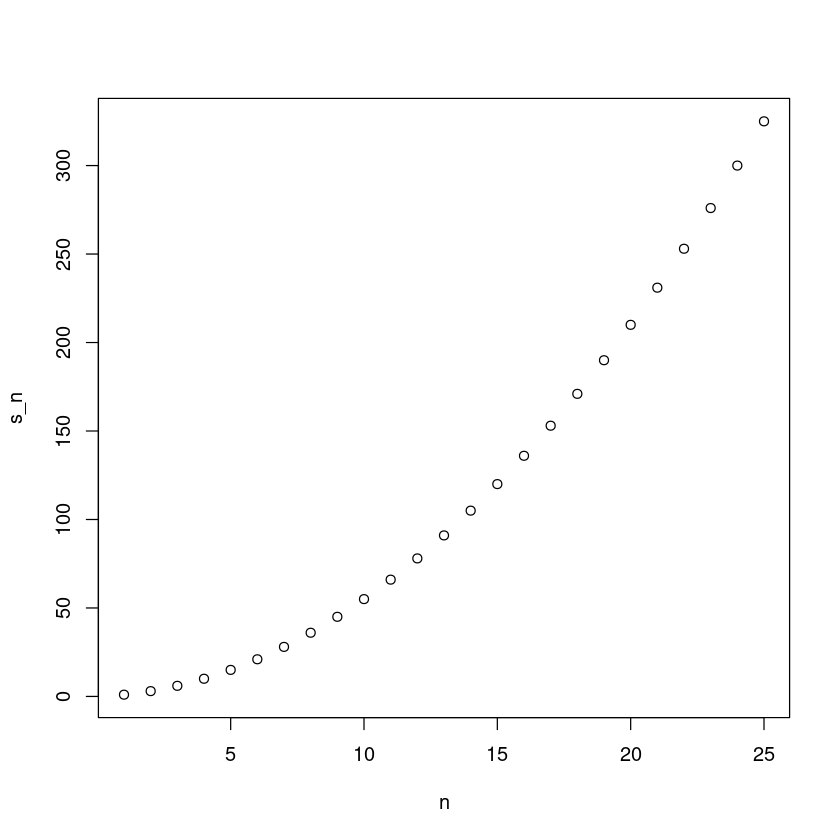

In [27]:
n <- 1:m
par(bg = 'white')
plot(n, s_n)

Switching back to the original definition of `compute_s_n` now:

In [28]:
compute_s_n <- function(n) {
    sum((1:n)^2)
}

## Vectorization and functionals

As mentioned, `for` loops are rare in R and vectorized operations are preferred. A vectorized function is one that will apply the same operation on each element of a vector:

In [29]:
x <- 1:10
sqrt(x)

[1] 1.000000 1.414214 1.732051 2.000000 2.236068 2.449490 2.645751 2.828427
 [9] 3.000000 3.162278

In [30]:
y <- 1:10
x * y

[1]   1   4   9  16  25  36  49  64  81 100

Not all functions are automatically vectorized:

In [31]:
compute_s_n(x)

Warning message in 1:n:
“numerical expression has 10 elements: only the first used”


[1] 1

The higher-order function `sapply()` (what I believe to be the most commonly used of several functions with "apply" in their name—the "s" stands for "simplified") can be used to vectorize a function like `compute_s_n()`:

In [32]:
sapply(x, compute_s_n)

[1]   1   5  14  30  55  91 140 204 285 385

Now for the last few exercises. These are *really* easy:

**Exercise 8**: Define an empty numerical vector `s_n` of size 25 using `s_n <- vector('numeric', 25)` and store the results of $S_1, S_2, S_3, \ldots, S_{25}$ using a `for` loop:

In [33]:
s_n <- vector('numeric', m)

for (n in 1:m) {
    s_n[n] <- compute_s_n(n)
}

s_n

[1]    1    5   14   30   55   91  140  204  285  385  506  650  819 1015 1240
[16] 1496 1785 2109 2470 2870 3311 3795 4324 4900 5525

**Exercise 9**: Repeat exercise 8, but this time use `sapply()`:

In [34]:
sapply(1:m, compute_s_n)

[1]    1    5   14   30   55   91  140  204  285  385  506  650  819 1015 1240
[16] 1496 1785 2109 2470 2870 3311 3795 4324 4900 5525

**Exercise 10**: Plot $S_n$ versus $n$. Use points defined by $n = 1, 2, 3, \ldots, 25$:

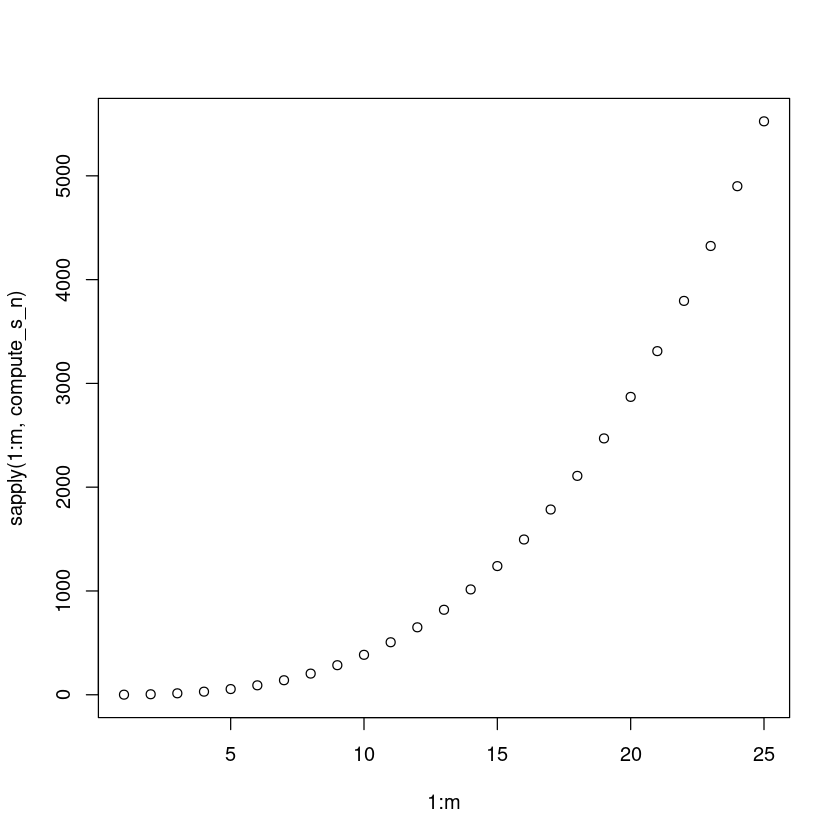

In [35]:
par(bg = 'white')
plot(1:m, sapply(1:m, compute_s_n))

**Exercise 11**: Confirm that the formula for this sum is

$$
S_n = \frac{n(n + 1)(2n + 1)}{6}
$$

In [36]:
compute_s_n_closed_form <- function(n) {
    (n * (n + 1) * (2 * n + 1)) / 6
}

In [37]:
x <- compute_s_n_closed_form(1:m)
x

[1]    1    5   14   30   55   91  140  204  285  385  506  650  819 1015 1240
[16] 1496 1785 2109 2470 2870 3311 3795 4324 4900 5525

In [38]:
y <- sapply(1:m, compute_s_n)
y

[1]    1    5   14   30   55   91  140  204  285  385  506  650  819 1015 1240
[16] 1496 1785 2109 2470 2870 3311 3795 4324 4900 5525

In [39]:
identical(x, y)

[1] TRUE